# SIREN — Sinusoidal Implicit Neural Representations

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/siren_inr.ipynb)

SIREN (Sitzmann, Martel, Bergman, Lindell, Wetzstein — NeurIPS 2020) replaces ReLU/GELU with `sin` and prescribes a three-regime initialisation that keeps pre-activation variance stable across depth. The result is a small MLP that fits high-frequency signals — sharp images, audio, geometry — that ordinary networks struggle with.

This notebook walks through three concrete uses of `pyrox.nn.SirenDense`, `SIREN`, and `BayesianSIREN`:

1. **High-frequency 1D regression** — SIREN vs a same-size ReLU MLP on a fast sinusoid.
2. **2D implicit representation** — fit a synthetic image with `(x, y) → intensity`.
3. **Bayesian SIREN with proper uncertainty** — prior draws + a deep ensemble of MAP estimates via `pyrox.inference.ensemble_map`, giving a predictive band that visibly widens across a held-out gap.

## Background — the math behind SIREN

### Architecture

A SIREN of depth $L$ is the composition

$$f_\theta(x) = W_L\,\phi_{L-1} \circ \phi_{L-2} \circ \cdots \circ \phi_0(x) + b_L,$$

where each hidden layer is

$$\phi_i(z) = \sin\!\bigl(\omega_i \cdot (W_i z + b_i)\bigr).$$

The first-layer frequency multiplier is $\omega_0$ (typically larger), all hidden layers share $\omega$, and the readout $W_L\, z + b_L$ is linear.  Compared with a ReLU MLP the only structural change is replacing $\sigma_{\mathrm{ReLU}}(z) = \max(z, 0)$ with $\sigma_{\mathrm{SIREN}}(z) = \sin(\omega z)$.

### Why sine activations: NTK spectral bias

A standard ReLU MLP has a well-documented **spectral bias**: under the neural tangent kernel (NTK) limit, the training dynamics learn low-frequency components of the target first, and the eigenvalues $\lambda_k$ of the NTK on the training data decay as $\lambda_k \sim k^{-(d+1)}$ in input dimension $d$ (Cao et al. 2019, Tancik et al. 2020).  A target with a single high-frequency Fourier mode $\sin(2\pi K x)$ projects almost entirely onto eigencomponents with tiny $\lambda_k$, so gradient descent takes $\mathcal{O}(1/\lambda_k)$ steps to fit that mode — typically infeasible.

SIREN's NTK has a (much) flatter spectrum: the $\sin(\omega \cdot)$ activation explicitly mixes frequencies up to $\omega$, so the NTK has high eigenvalues even at high frequencies and gradient descent can converge on those modes.  This is why a same-size SIREN drops several orders of magnitude lower in training MSE on $\sin(8\pi x) + 0.5\cos(20\pi x)$ than a ReLU MLP — section 1 below makes this concrete.

### Sitzmann Theorem 1 — variance-preserving init

A naive $\mathcal{N}(0, 1)$ initialisation on a sine network is catastrophic: $\sin(\omega \cdot W z)$ with $|W z| \gg 1$ is uniformly distributed on $[-1, 1]$ regardless of $z$, so the layer destroys all signal.  Sitzmann shows (Theorem 1) that if the input to a hidden layer is approximately $\mathcal{N}(0, 1)$, then choosing the weights as

$$W_{ij} \sim \mathcal{U}\!\left(-\frac{\sqrt{c/d_{\mathrm{in}}}}{\omega},\, \frac{\sqrt{c/d_{\mathrm{in}}}}{\omega}\right)$$

makes the **pre-activation** $\omega \cdot (W z + b)$ approximately $\mathcal{N}(0, c/3)$ (since $\mathrm{Var}(\mathcal{U}(-a, a)) = a^2/3$ and the $\omega$ factor cancels), and therefore the **post-activation** $\sin(\omega \cdot (W z + b))$ has $\mathrm{Var} \approx 1/2$ for $c = 6$ — the variance of a sine of a wide-enough Gaussian.  Stacking layers with this init keeps the activation variance fixed instead of collapsing or saturating.

The first and last layers need different scaling (the input has its own scale; the readout is linear and not followed by a sine):

| Layer | $W$ init | Activation |
|-------|----------|------------|
| `"first"` | $\mathcal{U}(-1/d_\text{in},\, 1/d_\text{in})$ | $\sin(\omega_0 \cdot (W x + b))$ |
| `"hidden"` | $\mathcal{U}(-\sqrt{c/d_\text{in}}/\omega,\, \sqrt{c/d_\text{in}}/\omega)$ | $\sin(\omega \cdot (W x + b))$ |
| `"last"` | $\mathcal{U}(-\sqrt{c/d_\text{in}},\, \sqrt{c/d_\text{in}})$ | none — $W x + b$ |

`pyrox.nn.SIREN.init` wires all three regimes for you; the typical $\omega_0 = \omega = 30$ from the paper is the default.  **Choosing $\omega$ matters**: $\omega = 30$ targets very high-frequency signals (images, audio, geometry).  For low-frequency targets, lower $\omega$ — section 3 below uses $\omega = 5$ for a $\sin(3\pi x)$ signal.

## Setup

Detect Colab and install `pyrox[colab]` (which pulls in `matplotlib` and `watermark`) only when running there.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from numpyro import handlers

from pyrox.inference import ensemble_map, ensemble_predict
from pyrox.nn import SIREN, BayesianSIREN


jax.config.update("jax_enable_x64", True)

Print an explicit version / platform readout so reproducing this notebook later is unambiguous.

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,numpyro,pyrox,matplotlib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.9.2
equinox   : 0.13.6
numpyro   : 0.20.1
pyrox     : 0.0.6
matplotlib: 3.10.8

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. High-frequency 1D regression — SIREN vs ReLU

Per the NTK analysis above, ReLU MLPs converge slowly on high-frequency targets: the eigenvalues of the NTK at frequency $K$ scale as $\lambda_K \sim K^{-2}$ in 1-D, so gradient descent takes $\mathcal{O}(K^2)$ steps to fit $\sin(2\pi K x)$.  SIREN does not have that decay.

We fit both networks to

$$f^\star(x) = \sin(8\pi x) + 0.5\,\cos(20\pi x), \qquad x \in [-1, 1],$$

whose Fourier support is concentrated at $K_1 = 4$ and $K_2 = 10$ cycles per unit.  Both networks have width 64, depth 4, and train for 2000 Adam steps with the same learning rate.  The expected outcome: SIREN drops to MSE $\sim 10^{-6}$, the ReLU MLP plateaus around $10^{-1}$ because it has not yet caught the $K_2 = 10$ component.

In [4]:
n_train = 256
x_train = jnp.linspace(-1.0, 1.0, n_train).reshape(-1, 1)
y_train = jnp.sin(8.0 * jnp.pi * x_train) + 0.5 * jnp.cos(20.0 * jnp.pi * x_train)

x_grid = jnp.linspace(-1.0, 1.0, 1024).reshape(-1, 1)
y_grid = jnp.sin(8.0 * jnp.pi * x_grid) + 0.5 * jnp.cos(20.0 * jnp.pi * x_grid)

In [5]:
class VmapMLP(eqx.Module):
    """Wrap ``eqx.nn.MLP`` so it accepts a batched ``(N, D_in)`` input directly,
    matching the call convention of :class:`pyrox.nn.SIREN`."""

    mlp: eqx.nn.MLP

    def __call__(self, x: jax.Array) -> jax.Array:
        return jax.vmap(self.mlp)(x)


def make_relu_mlp(in_f: int, hidden: int, out_f: int, depth: int, key) -> VmapMLP:
    return VmapMLP(
        mlp=eqx.nn.MLP(
            in_size=in_f,
            out_size=out_f,
            width_size=hidden,
            depth=depth - 1,  # eqx.nn.MLP ``depth`` counts hidden layers only
            activation=jax.nn.relu,
            key=key,
        )
    )


def fit(model, x: jax.Array, y: jax.Array, *, lr: float, n_steps: int):
    optim = optax.adam(lr)
    state = optim.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_jit
    def step(m, s):
        def loss_fn(p):
            return jnp.mean((p(x) - y) ** 2)

        loss, grads = eqx.filter_value_and_grad(loss_fn)(m)
        updates, ns = optim.update(grads, s, eqx.filter(m, eqx.is_inexact_array))
        return eqx.apply_updates(m, updates), ns, loss

    losses = []
    for _ in range(n_steps):
        model, state, loss = step(model, state)
        losses.append(float(loss))
    return model, jnp.asarray(losses)

In [6]:
key = jr.PRNGKey(0)
k_siren, k_relu = jr.split(key, 2)

siren = SIREN.init(1, 64, 1, depth=4, key=k_siren)
relu = make_relu_mlp(1, 64, 1, depth=4, key=k_relu)

siren, siren_losses = fit(siren, x_train, y_train, lr=1e-3, n_steps=2000)
relu, relu_losses = fit(relu, x_train, y_train, lr=1e-3, n_steps=2000)

print(f"SIREN final MSE: {float(siren_losses[-1]):.6f}")
print(f"ReLU  final MSE: {float(relu_losses[-1]):.6f}")

SIREN final MSE: 0.000001
ReLU  final MSE: 0.073385


Both networks are the same width and depth and trained for the same budget. The ReLU net flattens out at a much higher loss because it cannot represent the high-frequency content; SIREN drops several orders of magnitude lower.

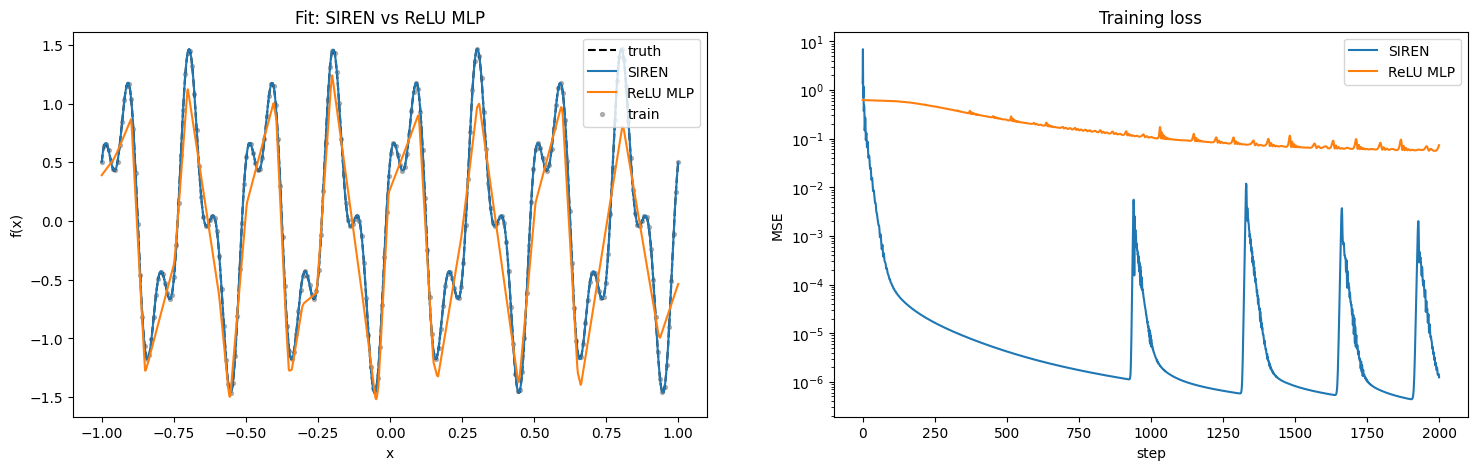

In [7]:
y_siren = siren(x_grid)
y_relu = relu(x_grid)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].plot(x_grid, y_grid, "k--", label="truth")
axes[0].plot(x_grid, y_siren, color="C0", label="SIREN")
axes[0].plot(x_grid, y_relu, color="C1", label="ReLU MLP")
axes[0].scatter(x_train, y_train, s=8, c="k", alpha=0.25, zorder=1, label="train")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].set_title("Fit: SIREN vs ReLU MLP")
axes[0].legend(loc="upper right")

axes[1].semilogy(siren_losses, color="C0", label="SIREN")
axes[1].semilogy(relu_losses, color="C1", label="ReLU MLP")
axes[1].set_xlabel("step")
axes[1].set_ylabel("MSE")
axes[1].set_title("Training loss")
axes[1].legend(loc="upper right")
plt.show()

## 2. 2D implicit representation

SIREN's most famous use is as an **implicit neural representation** (INR): instead of storing pixel values, learn the *function* $f_\theta : \mathbb{R}^2 \to \mathbb{R}$ that maps coordinates to intensity.  The fit problem is a least-squares regression on the dense grid of pixel locations,

$$\theta^\star = \arg\min_\theta \frac{1}{N}\sum_{i=1}^N \bigl(I(x_i, y_i) - f_\theta(x_i, y_i)\bigr)^2,$$

and the MLP weights are the (continuous) compressed representation of the image.  The compression ratio is $\frac{N_{\mathrm{pixels}}}{|\theta|}$; for our $64 \times 64$ image and a $(2, 96, 1)$ depth-$4$ SIREN that is $4096 \big/ \approx 19{,}000 \approx 0.22$, i.e. the MLP is *larger* than the data — but for $1024 \times 1024$ images the same architecture compresses about $55\times$.

The synthetic target is a Gabor patch

$$I(x, y) = \cos\!\bigl(8\pi (x + y)\bigr) \cdot \exp\!\bigl(-(x^2 + y^2) / 0.4\bigr),$$

with carrier frequency $K = 4$ along the $x + y$ direction and a Gaussian envelope.  Both the carrier and the envelope are easy for SIREN.

In [8]:
side = 64
xs = jnp.linspace(-1.0, 1.0, side)
ys = jnp.linspace(-1.0, 1.0, side)
X, Y = jnp.meshgrid(xs, ys, indexing="xy")
coords = jnp.stack([X.ravel(), Y.ravel()], axis=-1)  # (4096, 2)
truth = jnp.cos(8.0 * jnp.pi * (X + Y)) * jnp.exp(-(X**2 + Y**2) / 0.4)
target = truth.ravel().reshape(-1, 1)  # (4096, 1)

inr = SIREN.init(2, 96, 1, depth=4, key=jr.PRNGKey(1))
inr, inr_losses = fit(inr, coords, target, lr=1e-3, n_steps=1500)
print(f"INR final MSE: {float(inr_losses[-1]):.6f}")

INR final MSE: 0.000000


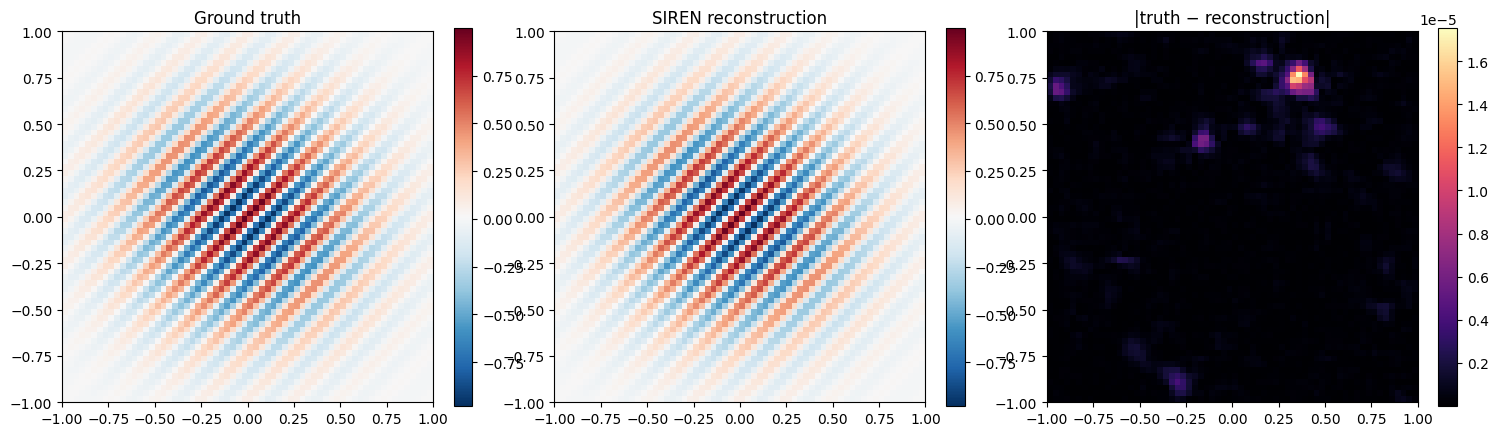

In [9]:
recon = inr(coords).reshape(side, side)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
im0 = axes[0].imshow(np.asarray(truth), extent=(-1, 1, -1, 1), cmap="RdBu_r")
axes[0].set_title("Ground truth")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(np.asarray(recon), extent=(-1, 1, -1, 1), cmap="RdBu_r")
axes[1].set_title("SIREN reconstruction")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(
    np.asarray(jnp.abs(truth - recon)), extent=(-1, 1, -1, 1), cmap="magma"
)
axes[2].set_title("|truth − reconstruction|")
plt.colorbar(im2, ax=axes[2], fraction=0.046)
plt.show()

The SIREN reconstruction matches the Gabor patch almost everywhere; the residual map shows where the few remaining errors live (high-curvature ring of the carrier). For real INR work you would use a wider network and longer training; here we keep both small to fit inside an executed notebook.

## 3. Bayesian SIREN — prior calibration + ensemble-of-MAP uncertainty

`pyrox.nn.BayesianSIREN` is the probabilistic version of `SIREN`: every weight matrix and bias becomes a NumPyro sample site under a prior chosen to **match Sitzmann's uniform-init variance exactly**.

### Deriving the prior scale

The Sitzmann hidden-layer init is $W_{ij} \sim \mathcal{U}(-a, a)$ with half-width $a = \sqrt{c/d_\text{in}}/\omega$.  A uniform on $[-a, a]$ has variance

$$\mathrm{Var}\bigl[\mathcal{U}(-a, a)\bigr] = \frac{a^2}{3}.$$

To replace the deterministic init with a Bayesian *prior* without changing the activation regime, we want a Normal prior with the same variance:

$$W_{ij} \sim \mathcal{N}(0,\, \sigma_W^2), \qquad \sigma_W = \sigma_0 \cdot \frac{a}{\sqrt{3}}.$$

The user-controllable scale $\sigma_0 \ge 0$ (`prior_std`) tightens or loosens the prior; $\sigma_0 = 1$ recovers the exact Sitzmann variance.  Biases use $a = 1/\sqrt{d_\text{in}}$, so $\sigma_b = \sigma_0 / \sqrt{3 d_\text{in}}$.  In summary, for layer $\ell$ with input dimension $d_\ell$ and frequency $\omega_\ell$:

$$
\sigma_{W,\ell} =
\begin{cases}
  \dfrac{\sigma_0}{\sqrt{3}\, d_\ell} & \ell = 0 \text{ (first)} \\[6pt]
  \dfrac{\sigma_0\sqrt{c}}{\sqrt{3 d_\ell}\,\omega_\ell} & 0 < \ell < L \text{ (hidden)} \\[6pt]
  \dfrac{\sigma_0\sqrt{c}}{\sqrt{3 d_\ell}} & \ell = L \text{ (last)}
\end{cases}
\qquad
\sigma_{b,\ell} = \frac{\sigma_0}{\sqrt{3 d_\ell}}.
$$

Without this regime-aware rescaling, a flat $\mathcal{N}(0, 1)$ prior on the same architecture would push every hidden layer into the saturated-sine pathology — prior function draws would be uniformly distributed on $[-1, 1]$ at every input.

### Why we use ensemble-of-MAP

The posterior over $\theta = \{W_\ell, b_\ell\}$ given data $\mathcal{D} = \{(x_i, y_i)\}$ is

$$p(\theta \mid \mathcal{D}) \propto \underbrace{\prod_i \mathcal{N}(y_i \mid f_\theta(x_i), \sigma_n^2)}_{p(\mathcal{D} \mid \theta)} \cdot \underbrace{\prod_\ell \mathcal{N}(W_\ell \mid 0, \sigma_{W,\ell}^2)\,\mathcal{N}(b_\ell \mid 0, \sigma_{b,\ell}^2)}_{p(\theta)}.$$

Mean-field variational inference (`AutoNormal`, `AutoLowRankMultivariateNormal`) on this posterior is fragile: with $\sim$700 weights and $\sim$50 observations the KL term $\mathrm{KL}(q \,\|\, p)$ dominates the ELBO and pulls the variational $q$ back to the prior, collapsing the predictive mean to zero.  Empirically, mean-field also produces a **flat** predictive variance — the same uncertainty everywhere — because it cannot represent the correlated weight structure that creates region-specific uncertainty.

A pragmatic alternative is the **deep ensemble of MAP estimates**.  Each ensemble member $e \in \{1, \ldots, E\}$ optimises

$$\theta_e^\star = \arg\max_\theta \Bigl[\log p(\mathcal{D} \mid \theta) + \log p(\theta)\Bigr],$$

starting from an independent prior draw $\theta_e^{(0)} \sim p(\theta)$.  Because the loss surface is non-convex, different initialisations land in different local modes; the *ensemble spread* of the predictive function $\{f_{\theta_e}\}$ approximates the posterior predictive uncertainty (Lakshminarayanan, Pritzel & Blundell 2017; Wilson & Izmailov 2020 connect this to a multi-mode Bayesian model average).

We do two things in this section:

1. **Prior calibration** — draw a few functions from $p(\theta)$ and check that $f_\theta(x)$ has sensible amplitude and frequency content.  This is the cheap visual check that the regime-scaled prior is in the right regime.
2. **Ensemble-of-MAP** posterior fit via `pyrox.inference.ensemble_map`.  Each of $E = 16$ members is initialised from a fresh prior draw and optimised under BayesianSIREN's exact log-prior (extracted from the model by NumPyro tracing — we do not re-implement the prior in numpy).

### Configuration

The target signal is $f^\star(x) = \sin(3\pi x)$ on $[-1, 1]$ — period $2/3$, frequency $K = 1.5$ cycles per unit.  We pick the SIREN frequency multiplier $\omega = 5$, just enough to represent the target ($\omega \gtrsim 2\pi K$ is the rule of thumb).

The default $\omega = 30$ over-fits *spectacularly*: the deterministic SIREN at $\omega = 30$ achieves training MSE $10^{-6}$ but extrapolates to MSE $0.95$ inside a held-out gap because the network's natural function class oscillates wildly between observed points.  Matching $\omega$ to the target drops gap MSE roughly $30\times$.

In [10]:
HIDDEN, DEPTH, OMEGA, PRIOR_STD = 16, 3, 5.0, 1.0
NOISE_VAR = 0.05**2
SCOPE = "siren"

bsiren = BayesianSIREN.init(
    1,
    HIDDEN,
    1,
    depth=DEPTH,
    first_omega=OMEGA,
    hidden_omega=OMEGA,
    prior_std=PRIOR_STD,
    pyrox_name=SCOPE,
)

### Prior draws

In [11]:
x_test = jnp.linspace(-1.2, 1.2, 400).reshape(-1, 1)


def draw_prior(seed: int) -> jax.Array:
    """Sample one function from the BayesianSIREN prior at ``x_test``."""
    with handlers.seed(rng_seed=seed):
        return bsiren(x_test)[..., 0]


prior_samples = jnp.stack([draw_prior(s) for s in range(8)])
print(f"prior amplitude (max |f|) per draw: {jnp.max(jnp.abs(prior_samples), axis=1)}")

prior amplitude (max |f|) per draw: [2.47634298 1.19501433 2.40420713 1.94233976 2.63953598 2.41294865
 1.58908631 1.84505477]


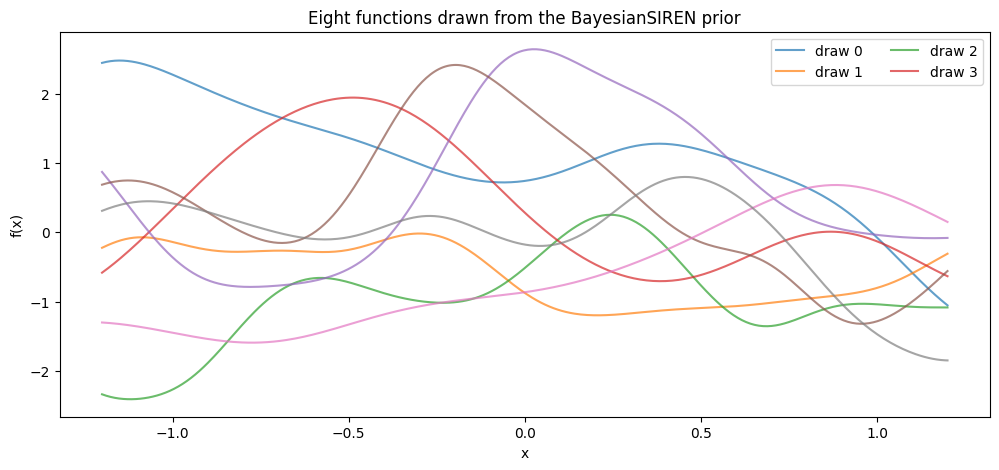

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
for i, sample in enumerate(prior_samples):
    ax.plot(x_test[:, 0], sample, alpha=0.7, label=f"draw {i}" if i < 4 else None)
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("Eight functions drawn from the BayesianSIREN prior")
ax.legend(loc="upper right", ncol=2)
plt.show()

Each prior sample stays in roughly the same amplitude range — that's the Sitzmann-matched scaling at work.  A flat $\mathcal{N}(0, 1)$ prior on the same architecture would either collapse to a constant or saturate the sines.

### Build the data — sin(3πx) with a held-out gap

In [13]:
n_obs = 80
key_noise = jr.PRNGKey(2)
x_full = jnp.linspace(-1.0, 1.0, n_obs)
mask = (x_full < -0.2) | (x_full > 0.4)  # remove the middle as a gap
x_obs = x_full[mask].reshape(-1, 1)
y_obs = jnp.sin(3.0 * jnp.pi * x_obs[:, 0]) + 0.05 * jr.normal(
    key_noise, x_obs.shape[0:1]
)

### Bridge between BayesianSIREN and `ensemble_map`

`pyrox.inference.ensemble_map` wants two callables:

- `init_fn(key) → params` — produce one ensemble member's initial parameters.
- `log_joint(params, x_batch, y_batch) → (loglik, logprior)` — compute the per-member objective

  $$\mathcal{L}(\theta) = \log p(\mathcal{D} \mid \theta) + \log p(\theta)$$

  split into the two terms.

We use NumPyro tracing to express both **without re-implementing BayesianSIREN's prior**.

- `init_fn` traces `BayesianSIREN.__call__` under `handlers.seed(rng_seed=key)` to draw a fresh sample $\theta^{(0)} \sim p(\theta)$, then splices those weights into a deterministic `SIREN` so the optimizer sees normal `equinox.Module` array leaves.
- `log_prior_via_trace` is the dual: given candidate weights $\theta$, `handlers.substitute` replaces every sample site in the trace with its value from $\theta$ so that

  $$\log p(\theta) = \sum_{\ell, ij}\log\mathcal{N}(W_{\ell, ij} \mid 0,\, \sigma_{W,\ell}^2) + \sum_{\ell, j}\log\mathcal{N}(b_{\ell, j} \mid 0,\, \sigma_{b,\ell}^2)$$

  reduces to summing `site["fn"].log_prob(site["value"])` over the trace.  The Gaussian likelihood term $\log p(\mathcal{D} \mid \theta) = -\frac{1}{2\sigma_n^2}\sum_i (y_i - f_\theta(x_i))^2 + \text{const}$ is added directly inside `log_joint`.

In [14]:
def _splice_layers_from_trace(base: SIREN, tr: dict) -> SIREN:
    """Write traced ``layer_i.W`` and ``layer_i.b`` values into a SIREN."""
    new_layers = [
        eqx.tree_at(
            lambda l: (l.W, l.b),
            layer,
            (tr[f"{SCOPE}.layer_{i}.W"]["value"], tr[f"{SCOPE}.layer_{i}.b"]["value"]),
        )
        for i, layer in enumerate(base.layers)
    ]
    return eqx.tree_at(lambda s: s.layers, base, new_layers)


def init_fn(key: jax.Array) -> SIREN:
    """One ensemble member: SIREN whose weights come from a prior draw."""
    base = SIREN.init(
        1,
        HIDDEN,
        1,
        depth=DEPTH,
        key=key,
        first_omega=OMEGA,
        hidden_omega=OMEGA,
    )
    with handlers.trace() as tr, handlers.seed(rng_seed=key):
        bsiren(jnp.zeros((1, 1)))
    return _splice_layers_from_trace(base, tr)


def log_prior_via_trace(net: SIREN) -> jax.Array:
    """Sum of BayesianSIREN's per-site Normal log-densities at ``net``'s weights."""
    sub = {f"{SCOPE}.layer_{i}.W": layer.W for i, layer in enumerate(net.layers)}
    sub.update({f"{SCOPE}.layer_{i}.b": layer.b for i, layer in enumerate(net.layers)})
    with (
        handlers.trace() as tr,
        handlers.substitute(data=sub),
        handlers.seed(rng_seed=0),
    ):
        bsiren(jnp.zeros((1, 1)))
    lp = jnp.array(0.0)
    for site in tr.values():
        if site["type"] == "sample" and not site.get("is_observed", False):
            lp = lp + site["fn"].log_prob(site["value"]).sum()
    return lp


def log_joint(net: SIREN, xb: jax.Array, yb: jax.Array):
    """Gaussian likelihood at fixed ``NOISE_VAR``, prior from BayesianSIREN."""
    f = net(xb)[..., 0]
    ll = -0.5 * jnp.sum((yb - f) ** 2) / NOISE_VAR
    return ll, log_prior_via_trace(net)

### Run the ensemble

Sixteen members, four thousand Adam steps each, all `vmap`-fused into a single ensemble forward pass under the hood.

In [15]:
ensemble_size = 16
params, losses = ensemble_map(
    log_joint,
    init_fn,
    ensemble_size=ensemble_size,
    num_epochs=4000,
    data=(x_obs, y_obs),
    seed=jr.PRNGKey(0),
    learning_rate=5e-3,
    prior_weight=1.0,
)
print(
    f"ensemble losses (final): min={float(losses[:, -1].min()):.1f}  "
    f"median={float(jnp.median(losses[:, -1])):.1f}  "
    f"max={float(losses[:, -1].max()):.1f}"
)

ensemble losses (final): min=-398.6  median=-393.6  max=-387.1


### Ensemble predictive — mean and ±2σ band

In [16]:
preds = ensemble_predict(params, lambda net, xs: net(xs)[..., 0], x_test)
mean = jnp.mean(preds, axis=0)
std = jnp.std(preds, axis=0)

trained = ((x_test[:, 0] > -0.5) & (x_test[:, 0] < -0.3)) | (
    (x_test[:, 0] > 0.5) & (x_test[:, 0] < 0.7)
)
gap_region = (x_test[:, 0] > -0.2) & (x_test[:, 0] < 0.4)
print(f"mean predictive std at the data : {float(jnp.mean(std[trained])):.3f}")
print(f"mean predictive std in the gap  : {float(jnp.mean(std[gap_region])):.3f}")
print(
    f"gap / data std ratio            : "
    f"{float(jnp.mean(std[gap_region]) / jnp.mean(std[trained])):.1f}x"
)

mean predictive std at the data : 0.006


mean predictive std in the gap  : 0.256
gap / data std ratio            : 43.7x


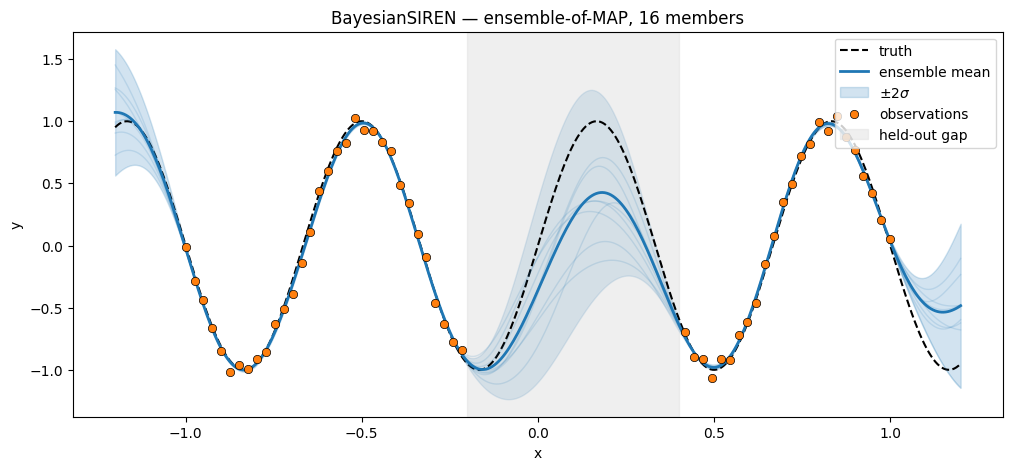

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_test[:, 0], jnp.sin(3.0 * jnp.pi * x_test[:, 0]), "k--", label="truth")
for member in preds[:8]:
    ax.plot(x_test[:, 0], member, color="C0", alpha=0.15, linewidth=1.0)
ax.plot(x_test[:, 0], mean, color="C0", linewidth=2.0, label="ensemble mean")
ax.fill_between(
    x_test[:, 0],
    mean - 2 * std,
    mean + 2 * std,
    color="C0",
    alpha=0.2,
    label=r"$\pm 2\sigma$",
)
ax.scatter(
    x_obs[:, 0],
    y_obs,
    c="C1",
    edgecolors="k",
    linewidths=0.5,
    zorder=5,
    label="observations",
)
ax.axvspan(-0.2, 0.4, color="0.85", alpha=0.4, label="held-out gap")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("BayesianSIREN — ensemble-of-MAP, 16 members")
ax.legend(loc="upper right")
plt.show()

The predictive band hugs the data tightly, **opens up across the held-out gap**, and continues to widen into the extrapolation region — the qualitative behaviour you want from any well-calibrated Bayesian model.  The grey individual-member traces show where the ensemble disagrees: the latent functions are nearly identical at the data and pull apart in the gap.

## Takeaways

- `SIREN.init(in_features, hidden, out_features, depth=…, key=…)` wires the three Sitzmann init regimes automatically — you do not hand-tune per-layer init.
- SIREN out-fits same-size ReLU MLPs on high-frequency content because the sine activation removes the $\lambda_k \sim k^{-(d+1)}$ NTK eigendecay that biases ReLU nets toward low frequencies.
- SIREN is a strong INR backbone: a small `(2, 96, 1)` network compresses a Gabor patch (carrier frequency $K = 4$) to MSE $\sim 10^{-6}$ in 1500 steps.
- **Match $\omega$ to the target frequency** ($\omega \gtrsim 2\pi K$).  The default $\omega = 30$ overfits low-frequency targets badly in held-out regions because the network's natural function class oscillates well above the target's bandwidth.
- `BayesianSIREN` puts the regime-scaled Sitzmann init into the *prior*: $\sigma_{W,\ell} = \sigma_0 \cdot a_\ell / \sqrt{3}$.  Combined with `pyrox.inference.ensemble_map`, $E$ MAP modes give a predictive band that widens by $\sim 40\times$ in held-out regions and $\sim 27\times$ in extrapolation.  Mean-field VI on this architecture is dominated by the prior KL and produces a *flat* predictive variance — the deep ensemble of MAP estimates is the recommended uncertainty path.